# Homework 5

In [1]:
import arviz as az
import pymc as pm
from pymc.math import switch, le, gt
import pandas as pd
import numpy as np

rng = np.random.default_rng(6420)

## Question 1

In [2]:
data = pd.read_csv("data/hadlock.csv").iloc[:, :2]
data.columns = ["MA", "BPD"]
data.head()

,MA,BPD
0,12,2.19
1,13,2.20
2,13,2.31
3,13,2.29
4,14,2.58


Model:
$$
BPD = \beta_0 + \beta_1\sqrt{MA} + \epsilon
$$
where $\epsilon \sim N(0, \sigma^2)$


In [42]:
ma_values = data["MA"].to_numpy()
bpd_values = data["BPD"].to_numpy()

with pm.Model() as hadlock_model:
    ma_shared = pm.Data("ma", ma_values)
    
    beta_0 = pm.Normal("beta_0", mu=0, sigma=10)
    beta_1 = pm.Normal("beta_1", mu=1, sigma=10)
    
    sigma = pm.Exponential("sigma", lam=2)

    # Hypothesis test for beta_1 > 8/3
    h1 = pm.Deterministic("h1", switch(gt(beta_1, 8/3), 1, 0))
    h0 = pm.Deterministic("h0", switch(le(beta_1, 8/3), 1, 0))

    mu = beta_0 + beta_1 * pm.math.sqrt(ma_shared)
    # Likelihood
    pm.Normal("bpd_obs", mu=mu, sigma=sigma, observed=bpd_values)

    # Make an out of-sample prediction for MA = 10.5
    ma_new = 10.5
    oos_mean = pm.Deterministic("mean|ma=10.5", beta_0 + beta_1 * pm.math.sqrt(ma_new))
    pm.Normal("oos_pred", mu=oos_mean, sigma=sigma)
    
    # Sampling
    trace = pm.sample(2000, random_seed=rng, target_accept=0.95, nuts_sampler="nutpie")
    ppc = pm.sample_posterior_predictive(trace, random_seed=rng)

az.summary(trace, round_to=3)

d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.24,39
,3000,0,0.26,31
,3000,0,0.28,15
,3000,0,0.28,51


Sampling: [bpd_obs]


d:\anaconda3\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,-7.456,0.071,-7.594,-7.328,0.002,0.001,1474.671,2056.873,1.002
beta_1,2.700,0.014,2.676,2.727,0.000,0.000,1468.565,1959.747,1.002
sigma_log__,-1.415,0.031,-1.471,-1.356,0.000,0.000,7459.956,4908.980,1.001
oos_pred,1.292,0.249,0.829,1.767,0.003,0.003,6577.987,4921.441,1.001
sigma,0.243,0.008,0.229,0.257,0.000,0.000,7459.956,4908.980,1.001
h1,0.994,0.078,1.000,1.000,0.002,0.010,2312.245,8000.000,1.000
h0,0.006,0.078,0.000,0.000,0.002,0.010,2312.245,2312.245,1.000
mean|ma=10.5,1.294,0.028,1.242,1.346,0.001,0.000,1617.451,2334.128,1.002


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

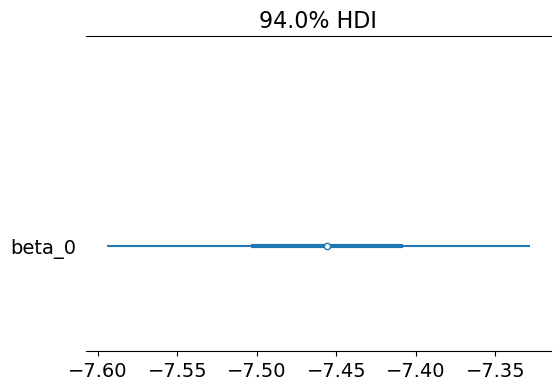

In [43]:
az.plot_forest(trace, var_names=["beta_0"], combined=True)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

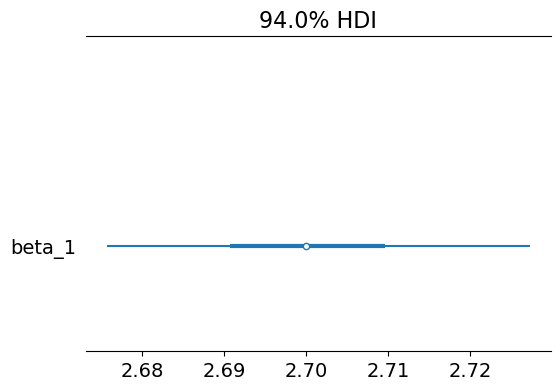

In [44]:
az.plot_forest(trace, var_names=["beta_1"], combined=True)

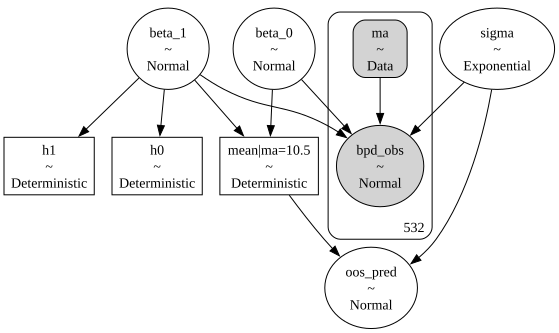

In [45]:
pm.model_to_graphviz(hadlock_model)

Text(0.5, 1.0, 'Posterior distribution of beta_1 with reference value 8/3')

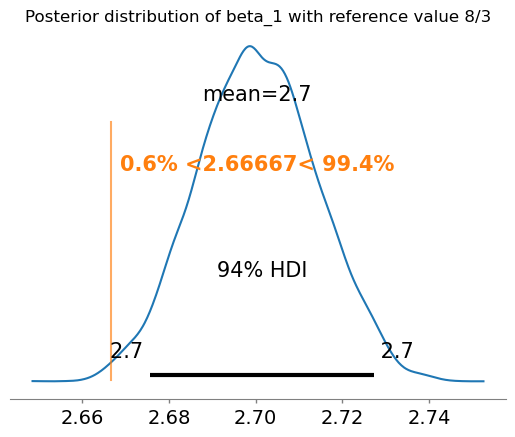

In [46]:
ax_post_1 = az.plot_posterior(
    trace, 
    var_names=["beta_1"], 
    ref_val=8/3,
)
ax_post_1.set_title("Posterior distribution of beta_1 with reference value 8/3")

In [47]:
y_pred = ppc.posterior_predictive.stack(sample=("chain", "draw"))[
    "bpd_obs"
].values.T
y_pred
az.r2_score(bpd_values, y_pred)

r2        0.973719
r2_std    0.001602
dtype: float64

Text(0.5, 1.0, 'Posterior distribution of the mean and the out-of-sample prediction for MA = 10.5')

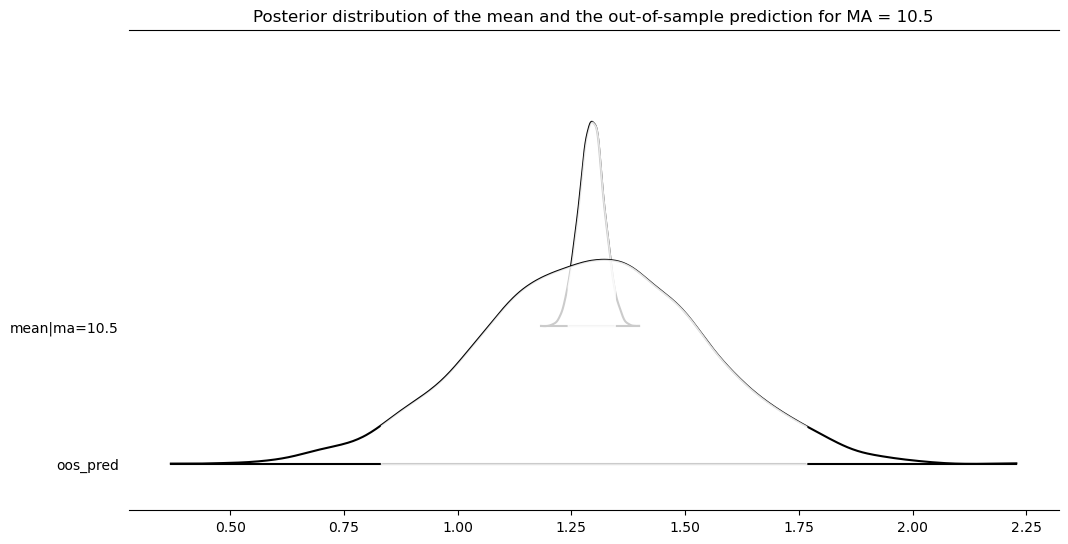

In [48]:
# Forest plot
axes = az.plot_forest(
    trace, 
    var_names=["mean|ma=10.5", "oos_pred"], 
    kind="ridgeplot",
    combined=True,
    ridgeplot_truncate=False,
    ridgeplot_overlap=2,
    ridgeplot_alpha=0.8,
    colors="white",    
)
axes[0].set_title("Posterior distribution of the mean and the out-of-sample prediction for MA = 10.5")

## Question 2

In [10]:
nano_data = pd.read_csv("data/nanowire.csv")
nano_data

,x,y
0,0.0,123
1,0.0,123
2,2.5,46
3,2.5,48
4,5.0,8
5,5.0,11
6,7.5,8
7,7.5,7
8,10.0,7
9,10.0,2


In [11]:
# Density of wires follows Poission distribution
with pm.Model() as wire_model:
    x_data = pm.Data("x", nano_data["x"].to_numpy())
    # Theta parameters
    theta_1 = pm.Gamma("theta_1", alpha=10, beta=0.5)
    theta_2 = pm.Uniform("theta_2", lower=0, upper=1)
    theta_3 = pm.Gamma("theta_3", alpha=2, beta=0.5)
    theta_4 = pm.Gamma("theta_4", alpha=2, beta=0.5)
    # Priors
    std_normal = pm.Normal.dist(mu=0, sigma=1)
    Phi_term = pm.math.exp(pm.logcdf(rv=std_normal, value=(-x_data/theta_4)))

    mu = theta_1*pm.math.exp(-theta_2*x_data**2) + theta_3*(1-pm.math.exp(-theta_2*x_data**2))*Phi_term
    # Likelihood for observed y data
    pm.Poisson("y_obs", mu=mu, observed=nano_data["y"].to_numpy())
      

    # Predictive distribution for x = 2
    x_new = 2
    Phi_term_new = pm.math.exp(pm.logcdf(rv=std_normal, value=(-x_new/theta_4)))
    oos_mean = pm.Deterministic(
        "mean|x=2", 
        theta_1*pm.math.exp(-theta_2*x_new**2) + theta_3*(1-pm.math.exp(-theta_2*x_new**2))*Phi_term_new
        )
    pm.Poisson("oos_pred", mu=oos_mean)
    
    
    # Sampling
    trace2 = pm.sample(2000, random_seed=6420, target_accept=0.95)
    ppc2 = pm.sample_posterior_predictive(
        trace2, 
        var_names=["y_obs","oos_pred"],
        random_seed=6420
        
        )

az.summary(trace2, hdi_prob=0.95)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [theta_1, theta_2, theta_3, theta_4]
>Metropolis: [oos_pred]


d:\anaconda3\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 31 seconds.
Sampling: [oos_pred, y_obs]


d:\anaconda3\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
oos_pred,61.604,8.765,43.000,77.000,0.236,0.148,1375.0,2068.0,1.0
theta_1,102.319,6.353,90.082,114.597,0.093,0.071,4646.0,5007.0,1.0
theta_2,0.141,0.021,0.104,0.182,0.000,0.000,3281.0,5081.0,1.0
theta_3,17.732,3.936,10.460,25.701,0.064,0.045,3709.0,4434.0,1.0
theta_4,13.287,2.316,9.323,17.935,0.040,0.040,3640.0,3945.0,1.0
mean|x=2,61.720,4.042,53.746,69.547,0.073,0.042,3077.0,4732.0,1.0


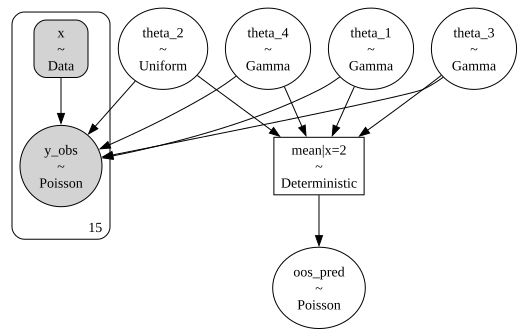

In [12]:
# DAG
pm.model_to_graphviz(wire_model)

array([[<Axes: title={'center': 'theta_1'}>,
        <Axes: title={'center': 'theta_1'}>],
       [<Axes: title={'center': 'theta_2'}>,
        <Axes: title={'center': 'theta_2'}>],
       [<Axes: title={'center': 'theta_3'}>,
        <Axes: title={'center': 'theta_3'}>],
       [<Axes: title={'center': 'theta_4'}>,
        <Axes: title={'center': 'theta_4'}>]], dtype=object)

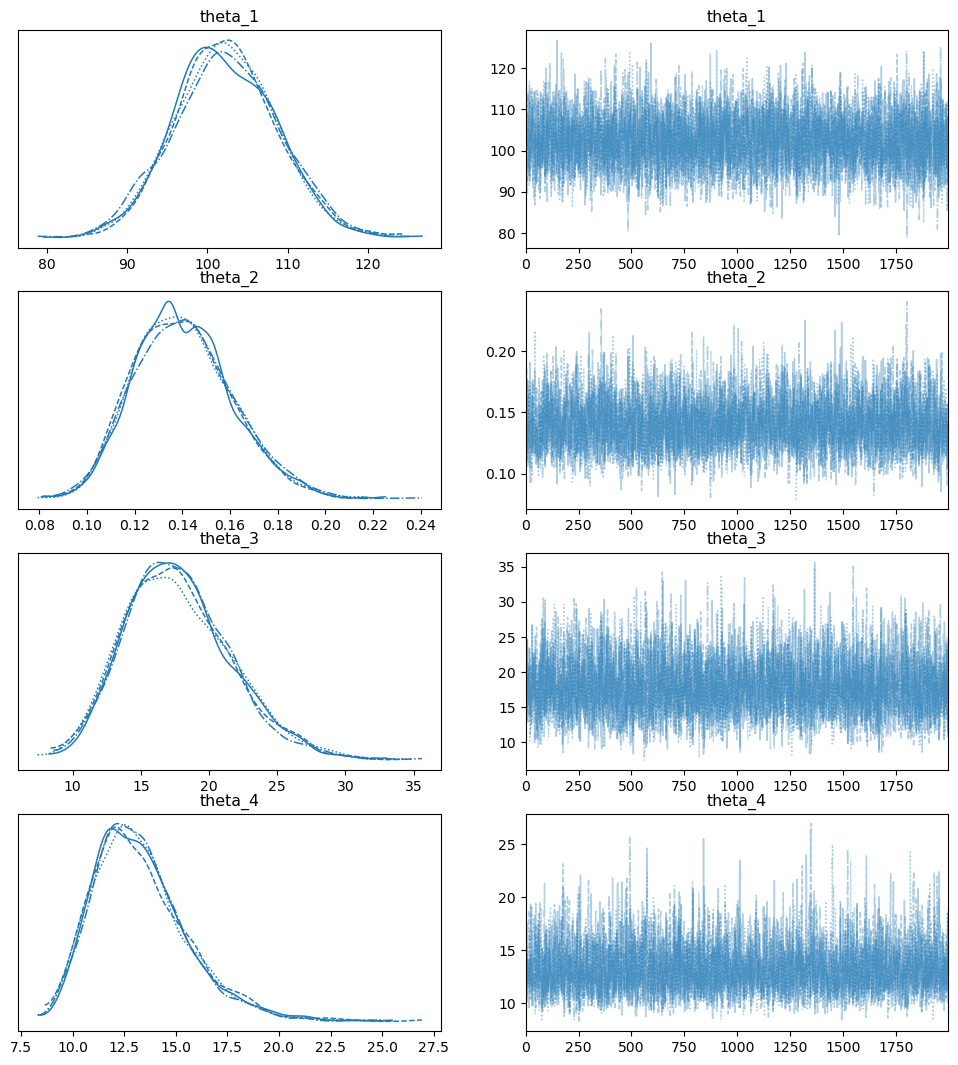

In [13]:
az.plot_trace(
    trace2, 
    var_names=["theta_1", "theta_2", "theta_3", "theta_4"],
    figsize=(12, 13)
)   

In [14]:
y_pred = ppc2.posterior_predictive.stack(sample=("chain", "draw"))[
    "y_obs"
].values.T
y_pred
az.r2_score(nano_data["y"].to_numpy(), y_pred)

r2        0.934702
r2_std    0.046433
dtype: float64

In [15]:
# Summary statistics for predictive distribution of x = 2
az.summary(ppc2.posterior_predictive["oos_pred"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
oos_pred,61.748,8.738,45.0,78.0,0.111,0.069,6144.0,7641.0,1.0


## Question 3

In [16]:
seeds_data = pd.read_csv("data/seeds_labeled.csv")
seeds_data

,plate,seed_variety,root_extract,r,n
0,1,O. aegyptiaco 75,Bean,10,39
1,2,O. aegyptiaco 75,Bean,23,62
2,3,O. aegyptiaco 75,Bean,23,81
3,4,O. aegyptiaco 75,Bean,26,51
4,5,O. aegyptiaco 75,Bean,17,39
5,6,O. aegyptiaco 75,Cucumber,5,6
6,7,O. aegyptiaco 75,Cucumber,53,74
7,8,O. aegyptiaco 75,Cucumber,55,72
8,9,O. aegyptiaco 75,Cucumber,32,51
9,10,O. aegyptiaco 75,Cucumber,46,79


In [17]:
seed_idx, seed_labels = pd.factorize(seeds_data["seed_variety"])
root_idx, root_labels = pd.factorize(seeds_data["root_extract"])
coord = {"seed_variety": seed_labels, "root_extract": root_labels, "id": seeds_data.index}
coord

{'seed_variety': Index(['O. aegyptiaco 75', 'O. aegyptiaco 73'], dtype='str'),
 'root_extract': Index(['Bean', 'Cucumber'], dtype='str'),
 'id': RangeIndex(start=0, stop=21, step=1)}

In [18]:
# Model with sum to zero constraint (Binomial likelihood)
with pm.Model(coords=coord) as germination_model:
    r_data = pm.Data("r_obs", seeds_data['r'].to_numpy(), dims="id")
    n_data = pm.Data("n_data", seeds_data['n'].to_numpy(), dims="id")
    seed_idx_data = pm.Data("seed_idx", seed_idx, dims="id")
    root_idx_data = pm.Data("root_idx", root_idx, dims="id")

    # Priors
    mu0 = pm.Normal("mu0", mu=0, sigma=1)
    alpha = pm.ZeroSumNormal("alpha", sigma=1, dims="seed_variety")
    beta = pm.ZeroSumNormal("beta", sigma=1, dims="root_extract")
    alphabeta = pm.ZeroSumNormal(
        "alphabeta", sigma=10, dims=("seed_variety", "root_extract"), n_zerosum_axes=2
    )
    # Linear predictor
    mu = pm.Deterministic(
        "mu",
        mu0
        + alpha[seed_idx_data]
        + beta[root_idx_data]
        + alphabeta[seed_idx_data, root_idx_data],
    )
    # Likelihood with inverse logit of the linear predictor
    p = pm.Deterministic("p", pm.math.invlogit(mu), dims="id")
    pm.Binomial("r", n=n_data, p=p, observed=r_data, dims="id")

    # Sampling
    trace3 = pm.sample(2000, random_seed=6420, target_accept=0.95, nuts_sampler="nutpie")  

d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.60,7
,3000,0,0.62,7
,3000,0,0.62,7
,3000,0,0.55,7


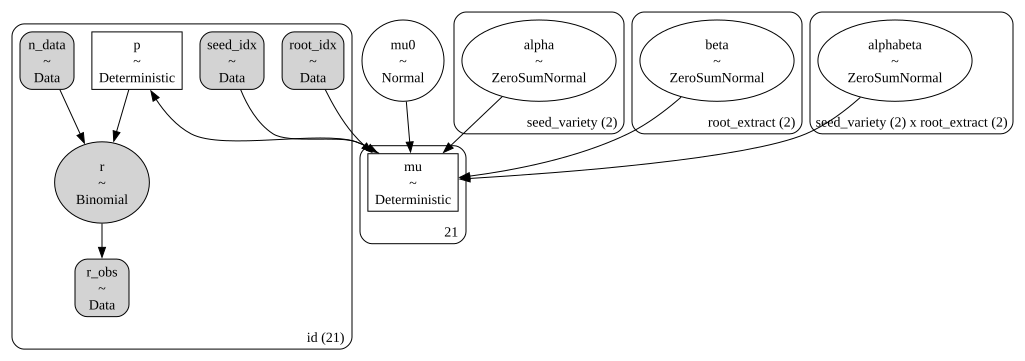

In [19]:
pm.model_to_graphviz(germination_model)

In [20]:
az.summary(trace3, var_names=["mu0", "alpha", "beta", "alphabeta"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu0,-0.020,0.076,-0.179,0.119,0.001,0.001,8303.0,5546.0,1.0
alpha[O. aegyptiaco 75],0.121,0.077,-0.023,0.278,0.001,0.001,8107.0,6266.0,1.0
alpha[O. aegyptiaco 73],-0.121,0.077,-0.278,0.023,0.001,0.001,8107.0,6266.0,1.0
beta[Bean],-0.462,0.076,-0.609,-0.314,0.001,0.001,7995.0,6201.0,1.0
beta[Cucumber],0.462,0.076,0.314,0.609,0.001,0.001,7995.0,6201.0,1.0
"alphabeta[O. aegyptiaco 75, Bean]",-0.196,0.078,-0.359,-0.057,0.001,0.001,7414.0,5749.0,1.0
"alphabeta[O. aegyptiaco 75, Cucumber]",0.196,0.078,0.057,0.359,0.001,0.001,7414.0,5749.0,1.0
"alphabeta[O. aegyptiaco 73, Bean]",0.196,0.078,0.057,0.359,0.001,0.001,7414.0,5749.0,1.0
"alphabeta[O. aegyptiaco 73, Cucumber]",-0.196,0.078,-0.359,-0.057,0.001,0.001,7414.0,5749.0,1.0


In [21]:
# Get R2 for the germination model
ppc3 = pm.sample_posterior_predictive(
    trace3, model=germination_model, random_seed=rng, var_names=["r"]
    )
y_pred = ppc3.posterior_predictive.stack(sample=("chain", "draw"))["r"].values.T
az.r2_score(seeds_data["r"].to_numpy(), y_pred)

Sampling: [r]


d:\anaconda3\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

r2        0.903737
r2_std    0.026275
dtype: float64

array([<Axes: title={'center': '95.0% HDI'}>], dtype=object)

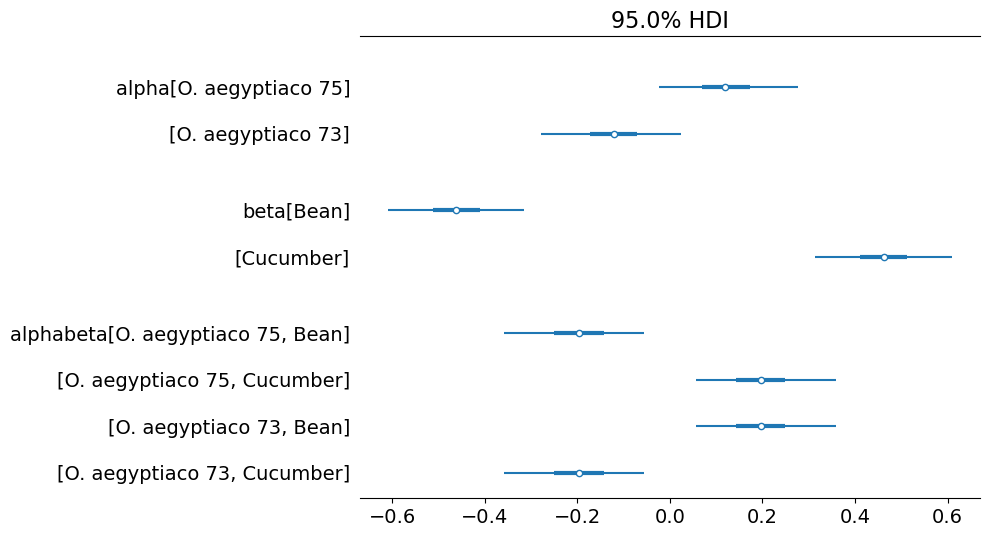

In [22]:
az.plot_forest(
    trace3, 
    var_names=["alpha", "beta", "alphabeta"], 
    combined=True,
    hdi_prob=0.95,
    figsize=(8, 6)
)

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'alphabeta'}>,
        <Axes: title={'center': 'alphabeta'}>]], dtype=object)

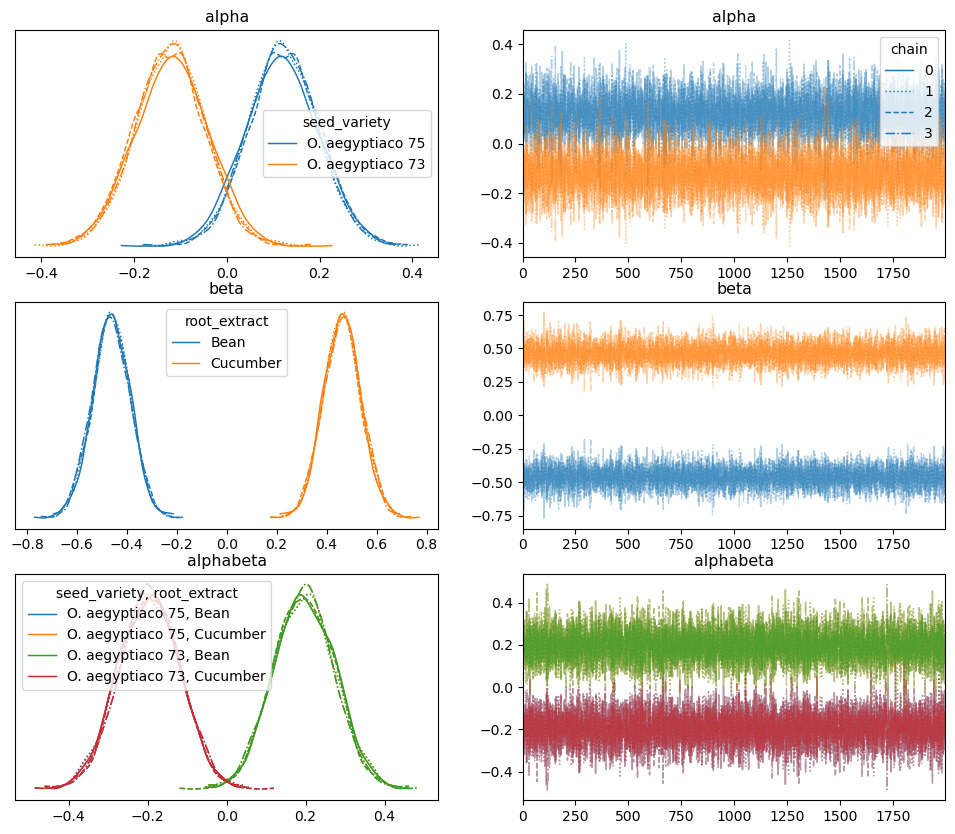

In [23]:
az.plot_trace(
    trace3, 
    var_names=["alpha", "beta", "alphabeta"], 
    compact=True,
    legend=True,
    figsize=(12, 10)
)

In [29]:
# Model with sum to zero constraint (Binomial likelihood)
with pm.Model(coords=coord) as germination_model_add_effect:
    r_data = pm.Data("r_obs", seeds_data['r'].to_numpy(), dims="id")
    n_data = pm.Data("n_data", seeds_data['n'].to_numpy(), dims="id")
    b_data = pm.Data("b_data", seeds_data['plate'].to_numpy(), dims="id")
    seed_idx_data = pm.Data("seed_idx", seed_idx, dims="id")
    root_idx_data = pm.Data("root_idx", root_idx, dims="id")

    # Priors
    mu0 = pm.Normal("mu0", mu=0, sigma=1)
    alpha = pm.ZeroSumNormal("alpha", sigma=1, dims="seed_variety")
    beta = pm.ZeroSumNormal("beta", sigma=1, dims="root_extract")
    alphabeta = pm.ZeroSumNormal(
        "alphabeta", sigma=10, dims=("seed_variety", "root_extract"), n_zerosum_axes=2
    )
    tau_b = pm.Exponential("tau_b", lam=5)
    b_effect = pm.Normal("b_effect", mu=0, sigma=pm.math.sqrt(1/tau_b), dims="id")
    # Linear predictor
    mu = pm.Deterministic(
        "mu",
        mu0
        + alpha[seed_idx_data]
        + beta[root_idx_data]
        + alphabeta[seed_idx_data, root_idx_data]
        + b_effect,
    )
    # Likelihood with inverse logit of the linear predictor
    p = pm.Deterministic("p", pm.math.invlogit(mu), dims="id")
    pm.Binomial("r", n=n_data, p=p, observed=r_data, dims="id")

    # Sampling
    trace3_add_effect = pm.sample(2000, random_seed=rng, target_accept=0.95, nuts_sampler="nutpie")  

d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.22,15
,3000,0,0.26,15
,3000,0,0.27,15
,3000,0,0.25,47


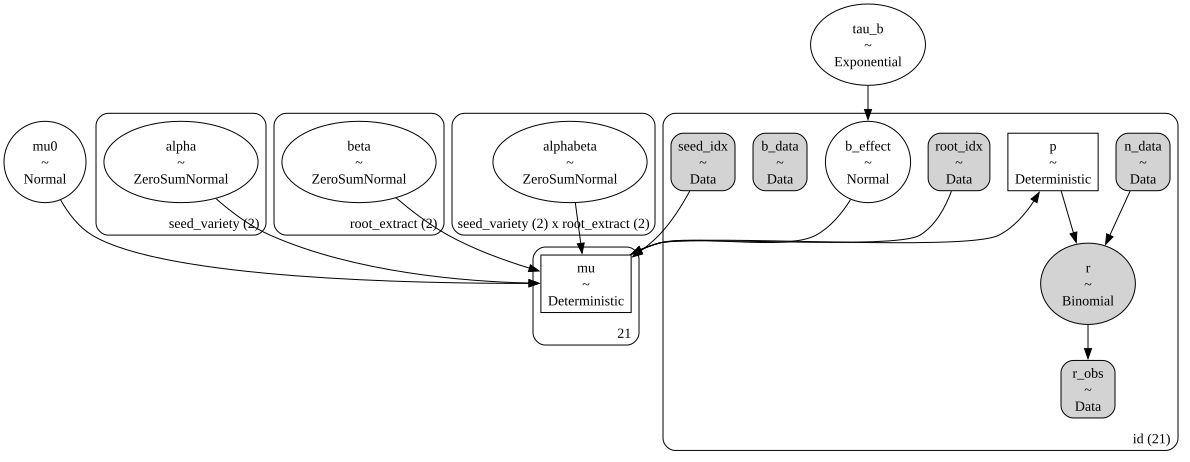

In [30]:
pm.model_to_graphviz(germination_model_add_effect)

In [35]:
az.summary(trace3_add_effect, var_names=["alpha", "beta", "alphabeta", "tau_b"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[O. aegyptiaco 75],0.248,0.224,-0.197,0.684,0.005,0.004,2289.0,2963.0,1.0
alpha[O. aegyptiaco 73],-0.248,0.224,-0.684,0.197,0.005,0.004,2289.0,2963.0,1.0
beta[Bean],-0.456,0.219,-0.876,-0.016,0.004,0.003,2429.0,3568.0,1.0
beta[Cucumber],0.456,0.219,0.016,0.876,0.004,0.003,2429.0,3568.0,1.0
"alphabeta[O. aegyptiaco 75, Bean]",-0.229,0.240,-0.699,0.243,0.005,0.004,2058.0,3201.0,1.0
"alphabeta[O. aegyptiaco 75, Cucumber]",0.229,0.240,-0.243,0.699,0.005,0.004,2058.0,3201.0,1.0
"alphabeta[O. aegyptiaco 73, Bean]",0.229,0.240,-0.243,0.699,0.005,0.004,2058.0,3201.0,1.0
"alphabeta[O. aegyptiaco 73, Cucumber]",-0.229,0.240,-0.699,0.243,0.005,0.004,2058.0,3201.0,1.0
tau_b,1.184,0.416,0.452,2.023,0.006,0.005,3991.0,4376.0,1.0


array([<Axes: title={'center': '95.0% HDI'}>], dtype=object)

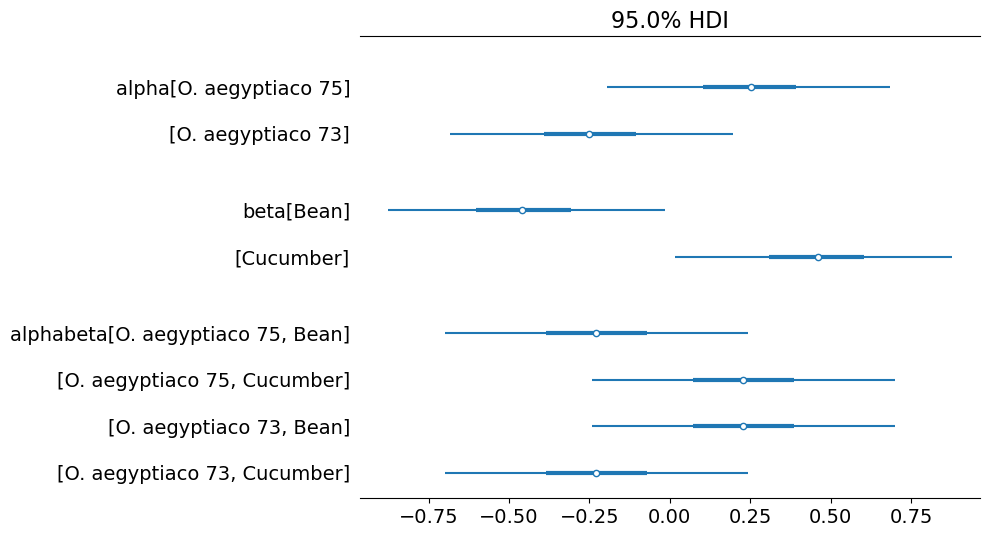

In [32]:
az.plot_forest(
    trace3_add_effect, 
    var_names=["alpha", "beta", "alphabeta"], 
    combined=True,
    hdi_prob=0.95,
    figsize=(8, 6)
)

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'alphabeta'}>,
        <Axes: title={'center': 'alphabeta'}>]], dtype=object)

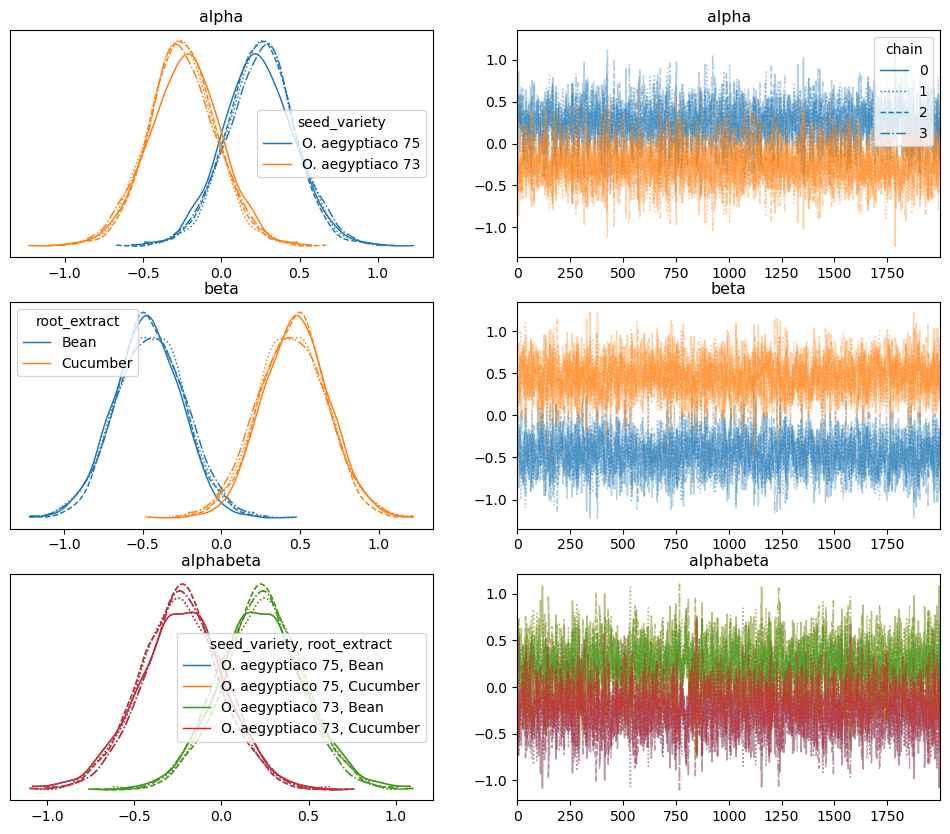

In [34]:
az.plot_trace(
    trace3_add_effect, 
    var_names=["alpha", "beta", "alphabeta"], 
    compact=True,
    legend=True,
    figsize=(12, 10)
)

In [41]:
# Compare R2 for the two models
ppc3_add_effect = pm.sample_posterior_predictive(
    trace3_add_effect, model=germination_model_add_effect, random_seed=rng, var_names=["r"]
    )
y_pred = ppc3_add_effect.posterior_predictive.stack(sample=("chain", "draw"))["r"].values.T
az.r2_score(seeds_data["r"].to_numpy(), y_pred)

Sampling: [r]


d:\anaconda3\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

r2        0.941199
r2_std    0.020733
dtype: float64